# IMAGE SEGMENTATION USING U-Net CNN (Rectangle)

## IMPORT LIBRARIES

In [1]:
import numpy as np  # numerical operations
import cv2  # image processing
import matplotlib.pyplot as plt  # visualization
from sklearn.model_selection import train_test_split  # dataset split
from tensorflow.keras.callbacks import EarlyStopping  # early stopping

In [2]:
from tensorflow.keras.layers import (
    Input,          # input layer
    Conv2D,         # convolution layer
    MaxPooling2D,   # downsampling
    UpSampling2D,   # upsampling
    Concatenate     # skip connections
)

from tensorflow.keras.models import Model  # U-Net model

## CONFIGURATION

In [3]:
Image_Size = 256  # input image size
sample = 1000

## DATASET

### CREATE

In [4]:
def create_dataset(samples=sample):

    images = []
    masks = []

    for _ in range(samples):

        img = np.zeros((Image_Size, Image_Size, 3),dtype=np.uint8)
        mask = np.zeros((Image_Size, Image_Size, 1),dtype=np.uint8)

        w = np.random.randint(20,50)
        h = np.random.randint(20,50)
        x = np.random.randint(5, Image_Size-w-5)
        y = np.random.randint(5, Image_Size-h-5)

        cv2.rectangle(img, (x, y), (x+w, y+h), (255,255,255), -1)
        cv2.rectangle(mask, (x, y), (x+w, y+h), 255, -1)

        images.append(img)
        masks.append(mask)

    return np.array(images), np.array(masks)

### GENERATE

In [5]:
X, y = create_dataset(sample)

print("=" * 60)
print("DATASET CREATED")
print("=" * 60)

print("Images Shape :", X.shape)
print("Labels/Masks :", y.shape)

DATASET CREATED
Images Shape : (1000, 256, 256, 3)
Labels/Masks : (1000, 256, 256, 1)


### NORMALIZATION

In [6]:
X = X.astype("float32") / 255.0
y = y.astype("float32") / 255.0

### TRAIN TEST SPLIT

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, shuffle=True)
print("=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)
print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)
print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

TRAIN / TEST SPLIT
Training Images : (800, 256, 256, 3)
Testing Images  : (200, 256, 256, 3)
Training Labels : (800, 256, 256, 1)
Testing Labels  : (200, 256, 256, 1)


## MODEL

### BUILD

In [8]:
def conv_block(x, filters):
    x = Conv2D(filters, (3,3), padding="same", activation="relu")(x)
    x = Conv2D(filters, (3,3), padding="same", activation="relu")(x)
    return x

inputs = Input(shape=(Image_Size, Image_Size, 3))

# ENCODER

c1 = conv_block(inputs, 32)
p1 = MaxPooling2D()(c1)

c2 = conv_block(p1, 64)
p2 = MaxPooling2D()(c2)

c3 = conv_block(p2, 128)
p3 = MaxPooling2D()(c3)

# BOTTLENECK

bn = conv_block(p3, 256)

# DECODER

u1 = UpSampling2D()(bn)
concat1 = Concatenate()([u1, c3])
c4 = conv_block(concat1, 128)

u2 = UpSampling2D()(c4)
concat2 = Concatenate()([u2, c2])
c5 = conv_block(concat2, 64)

u3 = UpSampling2D()(c5)
concat3 = Concatenate()([u3, c1])
c6 = conv_block(concat3, 32)

# OUTPUT LAYER

outputs = Conv2D(
    1,
    (1,1),
    activation="sigmoid"
)(c6)

model = Model(inputs, outputs)

### SUMMARY

In [9]:
print("="*60)
print("MODEL SUMMARY")
print("="*60)

model.summary()

MODEL SUMMARY


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ conv2d[0][0]      │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ conv2d_2[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_4[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 32, 32,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 32, 32,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 32, 32,    │    590,080 │ conv2d_6[0][0]    │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d       │ (None, 64, 64,    │          0 │ conv2d_7[0][0]    │
│ (UpSampling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 64, 64,    │          0 │ up_sampling2d[0]… │
│ (Concatenate)       │ 384)              │            │ conv2d_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_8 (Conv2D)   │ (None, 64, 64,    │    442,496 │ concatenate[0][0] │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_9 (Conv2D)   │ (None, 64, 64,    │    147,584 │ conv2d_8[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ up_sampling2d_1     │ (None, 128, 128,  │          0 │ conv2d_9[0][0]  

 Total params: 1,946,881 (7.43 MB)

 Trainable params: 1,946,881 (7.43 MB)

 Non-trainable params: 0 (0.00 B)

### COMPILE

In [10]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### EARLY STOPPING

In [11]:
early_stop = EarlyStopping(
    monitor="val_loss",  # monitor validation loss
    patience=3,  # stop if no improvement
    restore_best_weights=True  # keep best model
)

### TRAIN

In [12]:
history = model.fit(
    X_train, y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 56s 492ms/step - accuracy: 0.9932 - loss: 0.0817 - val_accuracy: 0.9969 - val_loss: 0.0095
Epoch 2/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 271ms/step - accuracy: 0.9994 - loss: 0.0017 - val_accuracy: 0.9999 - val_loss: 2.9577e-04
Epoch 3/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step - accuracy: 1.0000 - loss: 1.1510e-04 - val_accuracy: 1.0000 - val_loss: 3.5153e-05
Epoch 4/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 1.0000 - loss: 1.8250e-05 - val_accuracy: 1.0000 - val_loss: 7.8518e-06
Epoch 5/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 296ms/step - accuracy: 1.0000 - loss: 4.5847e-06 - val_accuracy: 1.0000 - val_loss: 2.3949e-06
Epoch 6/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 12s 299ms/step - accuracy: 1.0000 - loss: 1.5623e-06 - val_accuracy: 1.0000 - val_loss: 9.6307e-07
Epoch 7/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 287ms/step - accuracy: 1.0000 - loss: 7.2264e-07 - val_accuracy: 1.0000 - val_loss: 5.2780e-07
Epoch 8/20
40/40 ━━━━━━━━━━━━━━━━━━━━ 11s 280ms/step 

## LOSS PLOT

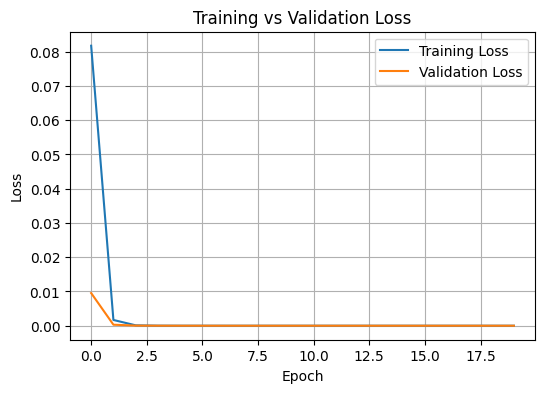

In [13]:
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label="Training Loss")  # training loss
plt.plot(history.history['val_loss'], label="Validation Loss")  # validation loss
plt.title("Training vs Validation Loss")  # title
plt.xlabel("Epoch")  # x-axis
plt.ylabel("Loss")  # y-axis
plt.title("Training vs Validation Loss")
plt.legend()  # legend
plt.grid(True)
plt.show()  # display graph

In [14]:
# U-net
test_loss, test_acc = model.evaluate(X_test, y_test)
print("\nTest Loss :", round(test_loss,4))
print(f"Test Accuracy : {test_acc:.2%}")

7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step - accuracy: 1.0000 - loss: 2.3751e-08

Test Loss : 0.0
Test Accuracy : 100.00%


## IoU FUNCTION

In [15]:
def IoU(mask1, mask2):

    mask1 = mask1.astype(bool)
    mask2 = mask2.astype(bool)

    intersection = np.logical_and(mask1, mask2).sum()
    union = np.logical_or(mask1, mask2).sum()

    return intersection / (union + 1e-6)

## VISUALIZATION (TRUE VS PREDICTED)

In [16]:
def draw_contours(img, mask, color):

    mask = (mask > 0.5).astype(np.uint8)
    contours, _ = cv2.findContours(mask.squeeze(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(img, contours, -1, color, 2)

In [17]:
preds = model.predict(X_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 253ms/step


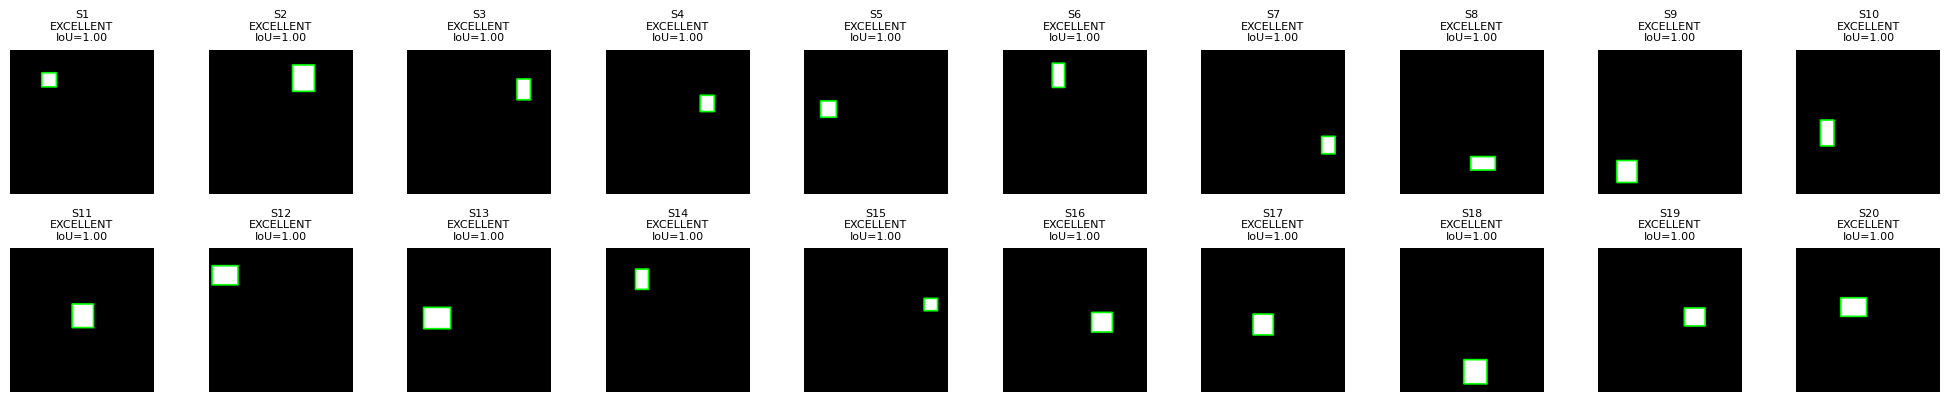

In [18]:
plt.figure(figsize=(20,20))

for i in range(min(len(X_test),20)):

    img = (X_test[i] * 255).astype(np.uint8).copy()

    # U-Net
    iou = IoU((preds[i] > 0.5).astype(np.uint8), (y_test[i] > 0.5).astype(np.uint8))
    draw_contours(img, y_test[i], (255,0,255))

    if iou >= 0.80:
        pred_color = (0,255,0)
        status = "EXCELLENT"
    elif iou >= 0.60:
        pred_color = (255,0,0)
        status = "GOOD"
    else:
        pred_color = (0,0,255)
        status = "WEAK"

    # U-Net
    draw_contours(img, preds[i], pred_color)

    plt.subplot(10,10,i+1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"S{i+1}\n{status}\nIoU={iou:.2f}", fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

## REPORT

In [19]:
ious = []

In [20]:
for i in range(len(preds)):
    pred_mask = (preds[i] > 0.5).astype(np.uint8)
    true_mask = (y_test[i] > 0.5).astype(np.uint8)
    ious.append(IoU(pred_mask, true_mask))

In [21]:
excellent = 0
good = 0
weak = 0

for iou in ious:
    if iou >= 0.80:
        excellent += 1
    elif iou >= 0.60:
        good += 1
    else:
        weak += 1

print("="*80)

# U-net
print("SEGMENTATION REPORT")

print("="*80)

for i in range(len(preds)):
    iou = ious[i]
    if iou >= 0.80:
        status = "✔ EXCELLENT"
    elif iou >= 0.60:
        status = "➜ GOOD"
    else:
        status = "✖ WEAK"
    print(f"\nSample {i+1}")
    print("-"*60)

    # U-Net
    pred_mask = (preds[i] > 0.5).astype(np.uint8)
    true_mask = (y_test[i] > 0.5).astype(np.uint8)
    print("True Pixels      :",int(np.sum(true_mask)))
    print("Predicted Pixels :",int(np.sum(pred_mask)))

    print("IoU :", round(iou,3))
    print("Status :", status)

SEGMENTATION REPORT

Sample 1
------------------------------------------------------------
True Pixels      : 702
Predicted Pixels : 702
IoU : 1.0
Status : ✔ EXCELLENT

Sample 2
------------------------------------------------------------
True Pixels      : 1920
Predicted Pixels : 1920
IoU : 1.0
Status : ✔ EXCELLENT

Sample 3
------------------------------------------------------------
True Pixels      : 950
Predicted Pixels : 950
IoU : 1.0
Status : ✔ EXCELLENT

Sample 4
------------------------------------------------------------
True Pixels      : 780
Predicted Pixels : 780
IoU : 1.0
Status : ✔ EXCELLENT

Sample 5
------------------------------------------------------------
True Pixels      : 870
Predicted Pixels : 870
IoU : 1.0
Status : ✔ EXCELLENT

Sample 6
------------------------------------------------------------
True Pixels      : 1012
Predicted Pixels : 1012
IoU : 1.0
Status : ✔ EXCELLENT

Sample 7
------------------------------------------------------------
True Pixels      

In [22]:
print("="*80)
print("FINAL SUMMARY")
print("="*80)
print("Total Samples :", len(ious))
print(f"Excellent (>=0.80) : {excellent} -> {(excellent/len(ious))*100:.2f}%")
print(f"Good (>=0.60) : {good} -> {(good/len(ious))*100:.2f}%")
print(f"Weak (<0.60) : {weak} -> {(weak/len(ious))*100:.2f}%")
print("Average IoU :", round(np.mean(ious),3))

FINAL SUMMARY
Total Samples : 200
Excellent (>=0.80) : 200 -> 100.00%
Good (>=0.60) : 0 -> 0.00%
Weak (<0.60) : 0 -> 0.00%
Average IoU : 1.0
